In [2]:
import jax.numpy as jnp
import sax
import sax.models as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
color = cm.rainbow(np.linspace(0, 1, 10))


# MODELS

In [3]:
#Definimos un modelo de guía dispersiva con los datos obtenidos en las simulaciones
wls_neff = jnp.linspace(1.5, 1.6, 200)
neffs = jnp.asarray([
    1.48511127, 1.48504885, 1.48498653, 1.48492431, 1.48486218,
    1.48480015, 1.48473821, 1.48467637, 1.48461462, 1.48455297,
    1.48449142, 1.48442996, 1.48436859, 1.48430732, 1.48424614,
    1.48418506, 1.48412407, 1.48406317, 1.48400237, 1.48394166,
    1.48388104, 1.48382052, 1.48376009, 1.48369976, 1.48363951,
    1.48357936, 1.48351930, 1.48345934, 1.48339946, 1.48333968,
    1.48327999, 1.48322039, 1.48316088, 1.48310146, 1.48304214,
    1.48298290, 1.48292376, 1.48286471, 1.48280574, 1.48274687,
    1.48268809, 1.48262940, 1.48257079, 1.48251228, 1.48245386,
    1.48239552, 1.48233728, 1.48227912, 1.48222105, 1.48216308,
    1.48210519, 1.48204738, 1.48198967, 1.48193205, 1.48187451,
    1.48181706, 1.48175970, 1.48170242, 1.48164524, 1.48158814,
    1.48153113, 1.48147420, 1.48141736, 1.48136061, 1.48130394,
    1.48124736, 1.48119087, 1.48113446, 1.48107814, 1.48102190,
    1.48096575, 1.48090968, 1.48085370, 1.48079780, 1.48074199,
    1.48068627, 1.48063062, 1.48057507, 1.48051959, 1.48046420,
    1.48040890, 1.48035368, 1.48029854, 1.48024348, 1.48018851,
    1.48013362, 1.48007882, 1.48002409, 1.47996945, 1.47991489,
    1.47986042, 1.47980603, 1.47975171, 1.47969748, 1.47964334,
    1.47958927, 1.47953529, 1.47948138, 1.47942756, 1.47937382,
    1.47932016, 1.47926658, 1.47921308, 1.47915966, 1.47910632,
    1.47905306, 1.47899988, 1.47894678, 1.47889376, 1.47884082,
    1.47878796, 1.47873518, 1.47868247, 1.47862985, 1.47857730,
    1.47852484, 1.47847245, 1.47842014, 1.47836791, 1.47831575,
    1.47826367, 1.47821167, 1.47815975, 1.47810791, 1.47805614,
    1.47800445, 1.47795284, 1.47790130, 1.47784984, 1.47779846,
    1.47774715, 1.47769592, 1.47764476, 1.47759368, 1.47754268,
    1.47749175, 1.47744090, 1.47739012, 1.47733942, 1.47728879,
    1.47723824, 1.47718776, 1.47713735, 1.47708702, 1.47703677,
    1.47698659, 1.47693648, 1.47688645, 1.47683649, 1.47678660,
    1.47673679, 1.47668705, 1.47663738, 1.47658778, 1.47653826,
    1.47648881, 1.47643944, 1.47639013, 1.47634090, 1.47629174,
    1.47624265, 1.47619363, 1.47614469, 1.47609582, 1.47604701,
    1.47599828, 1.47594962, 1.47590103, 1.47585251, 1.47580407,
    1.47575569, 1.47570738, 1.47565914, 1.47561098, 1.47556288,
    1.47551485, 1.47546689, 1.47541900, 1.47537118, 1.47532343,
    1.47527575, 1.47522814, 1.47518060, 1.47513312, 1.47508571,
    1.47503837, 1.47499110, 1.47494390, 1.47489677, 1.47484970,
    1.47480270, 1.47475577, 1.47470890, 1.47466211, 1.47461538,
    1.47456871, 1.47452212, 1.47447559, 1.47442912, 1.47438273,
])

def interp_neff(wl=1.55):
    """
    Interpola neff(wl) siguiendo el ejemplo oficial de SAX:
    se interpola frente a 1 / wl, no directamente frente a wl.

    wl en micras.
    """
    wl = jnp.asarray(wl)

    return jnp.interp(
        1 / wl,
        1 / wls_neff[::-1],
        neffs[::-1],
    )

def wg_disp(
    *,
    wl=1.55,
    length=10.0,
    loss=0.0,
):
    neff = interp_neff(wl)
    phase = 2 * jnp.pi * neff * length / wl
    amplitude = 10 ** (-loss * length / 20)
    transmission = amplitude * jnp.exp(1j * phase)

    return sax.reciprocal({
        ("in0", "out0"): transmission,
    })

def coupler(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi2x2(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi3x3() -> sax.SDict:
    coup = jnp.sqrt(1/3)
    mmi_dict = sax.reciprocal(
        {
            ("in0", "out0"): coup*jnp.exp( 1j* 2*jnp.pi /3),
            ("in0", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in0", "out2"): coup,

            ("in1", "out0"): coup*jnp.exp(-1j*jnp.pi /3),
            ("in1", "out1"): coup,
            ("in1", "out2"): coup*jnp.exp( -1j*jnp.pi /3),

            ("in2", "out0"): coup,
            ("in2", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in2", "out2"): coup*jnp.exp( 1j* 2*jnp.pi /3),

        }
    )

    return mmi_dict

# CIRCUIT

In [4]:

wvltracker, info = sax.circuit(
    netlist={
        "instances": {
            "mmi2x2": "mmi2x2",
            "wvg_u": "wg_disp",
            "wvg_d": "wg_disp",
            "mmi3x3": "mmi3x3",
        },
        "connections": {
            "mmi2x2,out0": "wvg_u,in0",
            "wvg_u,out0": "mmi3x3,in0",
            "mmi2x2,out1": "wvg_d,in0",
            "wvg_d,out0": "mmi3x3,in2",
        },
        "ports": {
            "in0": "mmi2x2,in0",
            "in1": "mmi2x2,in1",
            "out0": "mmi3x3,out0",
            "out1": "mmi3x3,out1",
            "out2": "mmi3x3,out2",
        },
    },
    models={
        "mmi2x2": mmi2x2,
        "wg_disp":wg_disp,
        "mmi3x3" : mmi3x3,
    },
)


<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_35617/3943276536.py:22: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta \lambda$ (pm)")


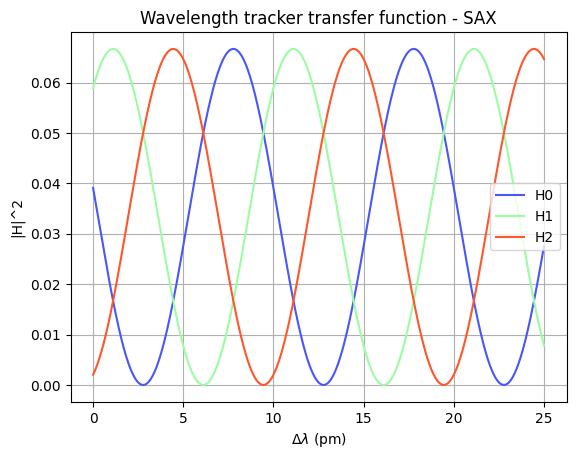

In [11]:
wls = jnp.linspace(1.55000, 1.550025, 1000)
loss_spiral = 10 * np.log10(19) / 146059.68378195382 # dB/um

test = wvltracker(wl = wls, 
                  wvg_u={"wl":wls, "length": 10, "loss":0},
                  wvg_d={"wl":wls, "length":  146059.68378195382, "loss":loss_spiral},)

h0 = test["in0", "out0"]
h1 = test["in0", "out1"]
h2 = test["in0", "out2"]

H0 = np.abs(h0)**2
H1 = np.abs(h1)**2
H2 = np.abs(h2)**2

wl0 = 1.55
dl_pm = (np.asarray(wls) - wl0) * 1e6  # um -> pm

plt.plot(dl_pm, H0, linestyle = '-', color = color[1], label = 'H0')
plt.plot(dl_pm, H1, linestyle = '-', color = color[5], label = 'H1')
plt.plot(dl_pm, H2, linestyle = '-', color = color[8], label = 'H2')
plt.xlabel("$\Delta \lambda$ (pm)")
plt.ylabel('|H|^2')
plt.title('Wavelength tracker transfer function - SAX')
plt.legend()
plt.grid(True)

plt.show()

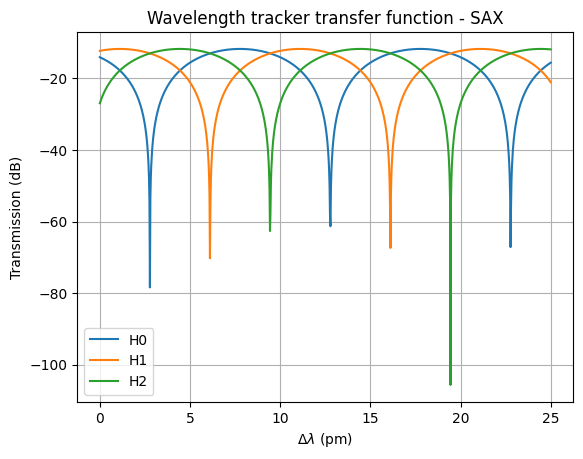

In [12]:
eps = 1e-15

H0_dB = 10 * np.log10(H0 + eps)
H1_dB = 10 * np.log10(H1 + eps)
H2_dB = 10 * np.log10(H2 + eps)


plt.plot(dl_pm, H0_dB, label="H0")
plt.plot(dl_pm, H1_dB, label="H1")
plt.plot(dl_pm, H2_dB, label="H2")

plt.xlabel(r"$\Delta\lambda$ (pm)")
plt.ylabel("Transmission (dB)")
plt.title("Wavelength tracker transfer function - SAX")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(H0)

peak_wls = np.asarray(wls)[peaks]
fsrs_pm = np.diff(peak_wls) * 1e6

print("FSR medio [pm]:", np.mean(fsrs_pm))
print("FSR std [pm]:", np.std(fsrs_pm))

FSR medio [pm]: 9.984984984834355
FSR std [pm]: 0.0
